In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def init_lattice(N):
    return np.random.choice([-1, 1], size=(N, N))

In [3]:
def local_field(lattice, i, j, k):
    N = lattice.shape[0]
    total = 0
    
    for di in range(-k, k+1):
        for dj in range(-k, k+1):
            if di == 0 and dj == 0:
                continue
            
            ni, nj = i + di, j + dj
            
            if 0 <= ni < N and 0 <= nj < N:
                total += lattice[ni, nj]
    
    return total

In [4]:
def gibbs_step(lattice, T, k):
    N = lattice.shape[0]
    
    for i in range(N):
        for j in range(N):
            
            h = local_field(lattice, i, j, k)
            
            # probability sigma = +1
            p = 1 / (1 + np.exp(-2 * h / T))
            
            lattice[i, j] = 1 if np.random.rand() < p else -1
    
    return lattice

In [5]:
def run_gibbs(N, T, k, steps=50):
    lattice = init_lattice(N)
    
    for _ in range(steps):
        lattice = gibbs_step(lattice, T, k)
    
    return lattice

In [6]:
def plot_lattice(lattice, title):
    plt.imshow(lattice, cmap='coolwarm')
    plt.title(title)
    plt.axis('off')
    plt.show()

Running T=0.5, k=1...


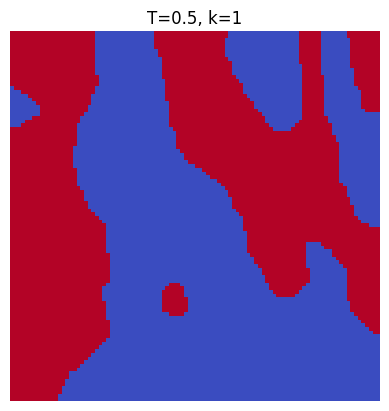

Running T=0.5, k=10...


/var/folders/r0/vg0qhqnj2ldgjjr41jf27xn00000gn/T/ipykernel_28904/1525073967.py:10: RuntimeWarning: overflow encountered in exp
  p = 1 / (1 + np.exp(-2 * h / T))


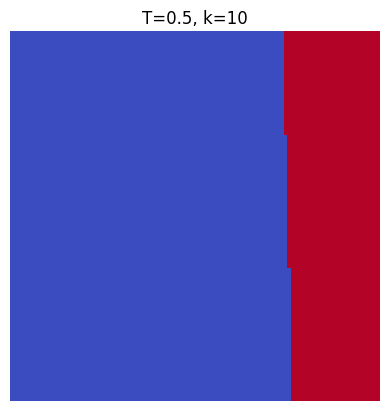

Running T=1.5, k=1...


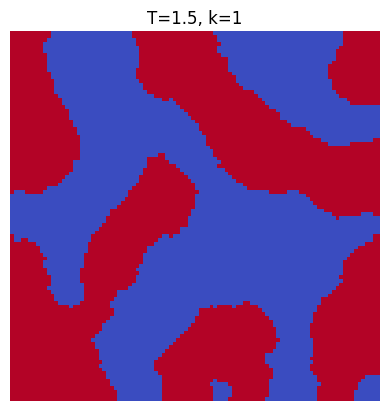

Running T=1.5, k=10...


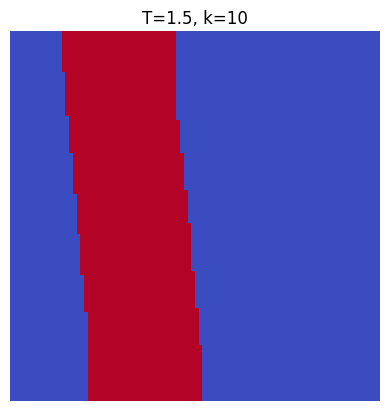

Running T=3, k=1...


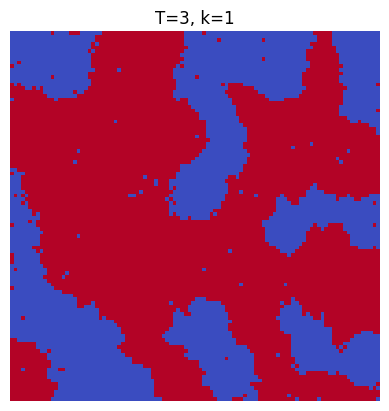

Running T=3, k=10...


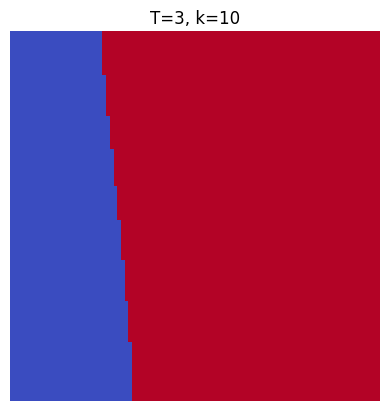

In [7]:
N = 100
Ts = [0.5, 1.5, 3]
ks = [1, 10]

for T in Ts:
    for k in ks:
        print(f"Running T={T}, k={k}...")
        lattice = run_gibbs(N, T, k, steps=30)
        plot_lattice(lattice, f"T={T}, k={k}")